<a href="https://colab.research.google.com/github/aghatescoding/DMS613-/blob/main/Black_ScholesTrading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Trading using the Black-Scholes Model


#### Solving the Black-Scholes Equation Yields
$$C = S_t \Phi(d_1) - Ke^{-rt} \Phi(d_2)$$

$$\Phi(x) = \int_{-\infty}^x \frac{1}{\sqrt{2\pi}}e^{\frac{-s^2}{2}}ds$$

$$d_1 = \frac{ln(\frac{S_t}{K})+(r+\frac{\sigma^2}{2})t}{\sigma \sqrt{t}}$$

$$d_2 = d_1 - \sigma \sqrt{t}$$

$$\frac{dS_t}{S_t} = \mu dt + \sigma dW_t$$

In [1]:
import numpy as np
from scipy.stats import norm

def black_scholes_call(S, K, sigma, r, t):
    if t <= 0:
        return max(S - K, 0)
    d1 = (np.log(S/K) + (r + ((sigma**2)/2))*t) / (sigma * np.sqrt(t))
    d2 = d1 - (sigma * np.sqrt(t))
    C = S * norm.cdf(d1) - K * np.exp(-r*t) * norm.cdf(d2)
    return C

black_scholes_call(100, 100, .3, .05, 1)

np.float64(14.231254785985819)

### Making and Losing Money Trading Options


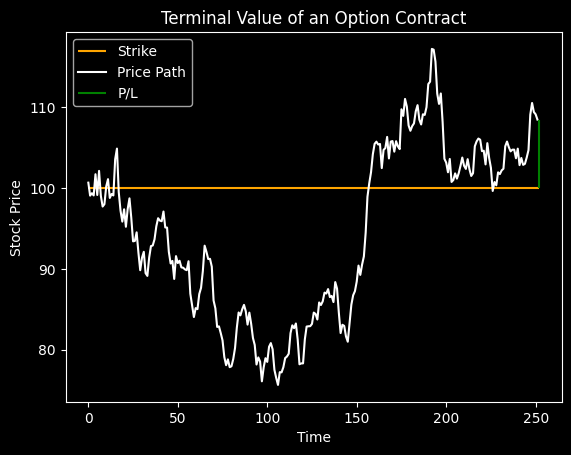

Premium at t=0: 14.231254785985819
P/L: -5.763888405512013


In [3]:
#Run this code twice to get the nice plot

!pip install qfin
import matplotlib.pyplot as plt
import qfin as qf

# simulate dynamics of the underlying according to Geometric Brownian Motion
path = qf.simulations.GeometricBrownianMotion(100, 0.05, .3, 1/252, 1)


# create a chart of the price path and the strike price
plt.title("Terminal Value of an Option Contract")
plt.hlines(100, 0, 252, label='Strike', color='orange')
plt.plot(path.simulated_path, label='Price Path', color='white')
if max(path.simulated_path[-1] - 100, 0) == 0:
    plt.vlines(252, path.simulated_path[-1], 100, color='red', label="P/L")
else:
    plt.vlines(252, 100, path.simulated_path[-1], color='green', label="P/L")
plt.style.use('dark_background')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.savefig('/content/terminal_value_option_contract.png') # Save plot
plt.show()

# print the premium and the resulting P/L
print("Premium at t=0:", black_scholes_call(100, 100, .3, .05, 1))
print("P/L:", max(path.simulated_path[-1] - 100, 0) - black_scholes_call(100, 100, .3, .05, 1))

### How to Make Money using the Black-Scholes Model

Let $T$ be a trading strategy such that options are bought/sold when there is a theoretical discrepency between the model price and market maker quote.

$$\mathbb{E}T > 0 \implies \text{ Positive P/L Over Time}$$

In [4]:
print("Call Price:", black_scholes_call(100, 100, .3, .05, 1))
print("Market Maker Quote:", "13.43 @ 14.10")
print("Trade Edge:", black_scholes_call(100, 100, .3, .05, 1) - 14.10)

Call Price: 14.231254785985819
Market Maker Quote: 13.43 @ 14.10
Trade Edge: 0.13125478598581886


### Computing the P/L Edge with Respect to the Model Dynamics

In [ ]:
premium = 14.10 * 100
pls = []

for i in range(100000):
    path = qf.simulations.GeometricBrownianMotion(100, 0.05, .3, 1/252, 1)
    pls.append(max(path.simulated_path[-1] - 100, 0)*100 - premium)

np.mean(pls)

np.float64(91.87723647770716)

### Simulating an Equity Curve Assuming Underlying Dynamics

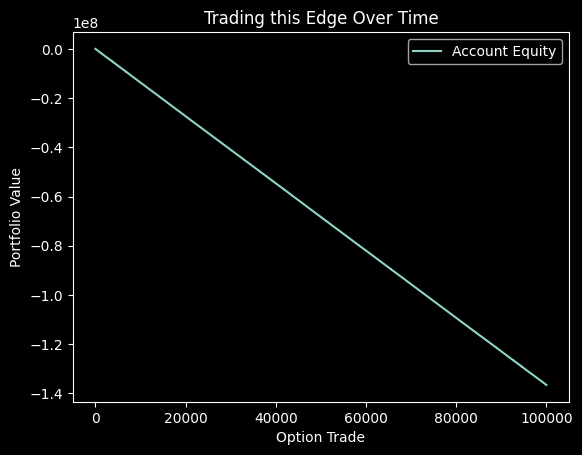

In [ ]:
premium = 14.10 * 100 #What is equity curve??
pls = []

for i in range(100000):
    path = qf.simulations.GeometricBrownianMotion(100, -.5, .3, 1/252, 1)
    pls.append(max(path.simulated_path[-1] - 100, 0)*100 - premium)

plt.title("Trading this Edge Over Time")
plt.plot(np.cumsum(pls), label="Account Equity")
plt.style.use('dark_background')
plt.xlabel('Option Trade')
plt.ylabel('Portfolio Value')
plt.legend()
plt.savefig('/content/trading_edge_equity_curve.png') # Save plot
plt.show()

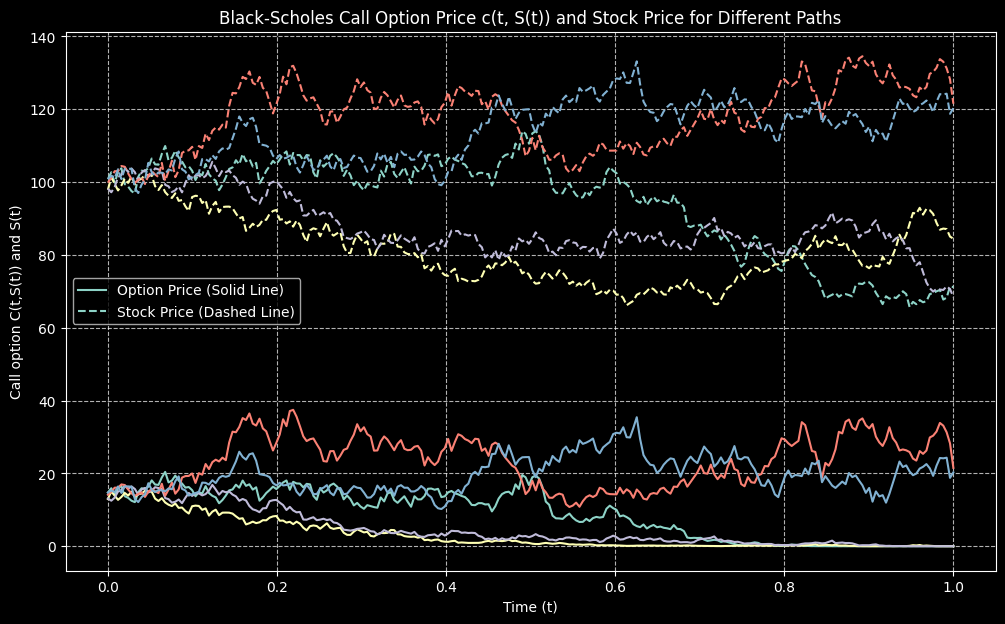

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define option parameters (from previous cells)
S0 = 100
K = 100
sigma = 0.3
r = 0.05
T = 1 # Total time in years
dt = 1/252 # Time step

# Number of simulation paths
num_paths = 5

plt.figure(figsize=(12, 7))
plt.style.use('dark_background')

# Get the default color cycle for consistent coloring
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

for i in range(num_paths):
    # Simulate a new stock price path
    path_sim = qf.simulations.GeometricBrownianMotion(S0, r, sigma, dt, T)
    stock_prices = path_sim.simulated_path

    # Generate time points for the path (from t=0 to t=T)
    time_points = np.linspace(0, T, len(stock_prices))

    option_prices = []
    for j in range(len(stock_prices)):
        current_S = stock_prices[j]
        current_time_to_maturity = T - time_points[j]

        # Avoid division by zero or log of zero if current_time_to_maturity is extremely close to 0
        # Also handle cases where current_time_to_maturity becomes negative due to floating point inaccuracies
        if current_time_to_maturity <= 0:
            # If time to maturity is zero or negative, the option price is its intrinsic value
            option_price = max(current_S - K, 0)
        else:
            option_price = black_scholes_call(current_S, K, sigma, r, current_time_to_maturity)
        option_prices.append(option_price)

    # Get a color from the cycle for the current path
    color = colors[i % len(colors)]

    # Plot option prices with solid line and stock prices with dashed line
    # Only label for the first path to avoid cluttering the legend
    if i == 0:
        plt.plot(time_points, option_prices, label='Option Price (Solid Line)', linestyle='-', color=color)
        plt.plot(time_points, stock_prices, label='Stock Price (Dashed Line)', linestyle='--', color=color)
    else:
        plt.plot(time_points, option_prices, linestyle='-', color=color)
        plt.plot(time_points, stock_prices, linestyle='--', color=color)

plt.title('Black-Scholes Call Option Price c(t, S(t)) and Stock Price for Different Paths')
plt.xlabel('Time (t)')
plt.ylabel('Call option C(t,S(t)) and S(t)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

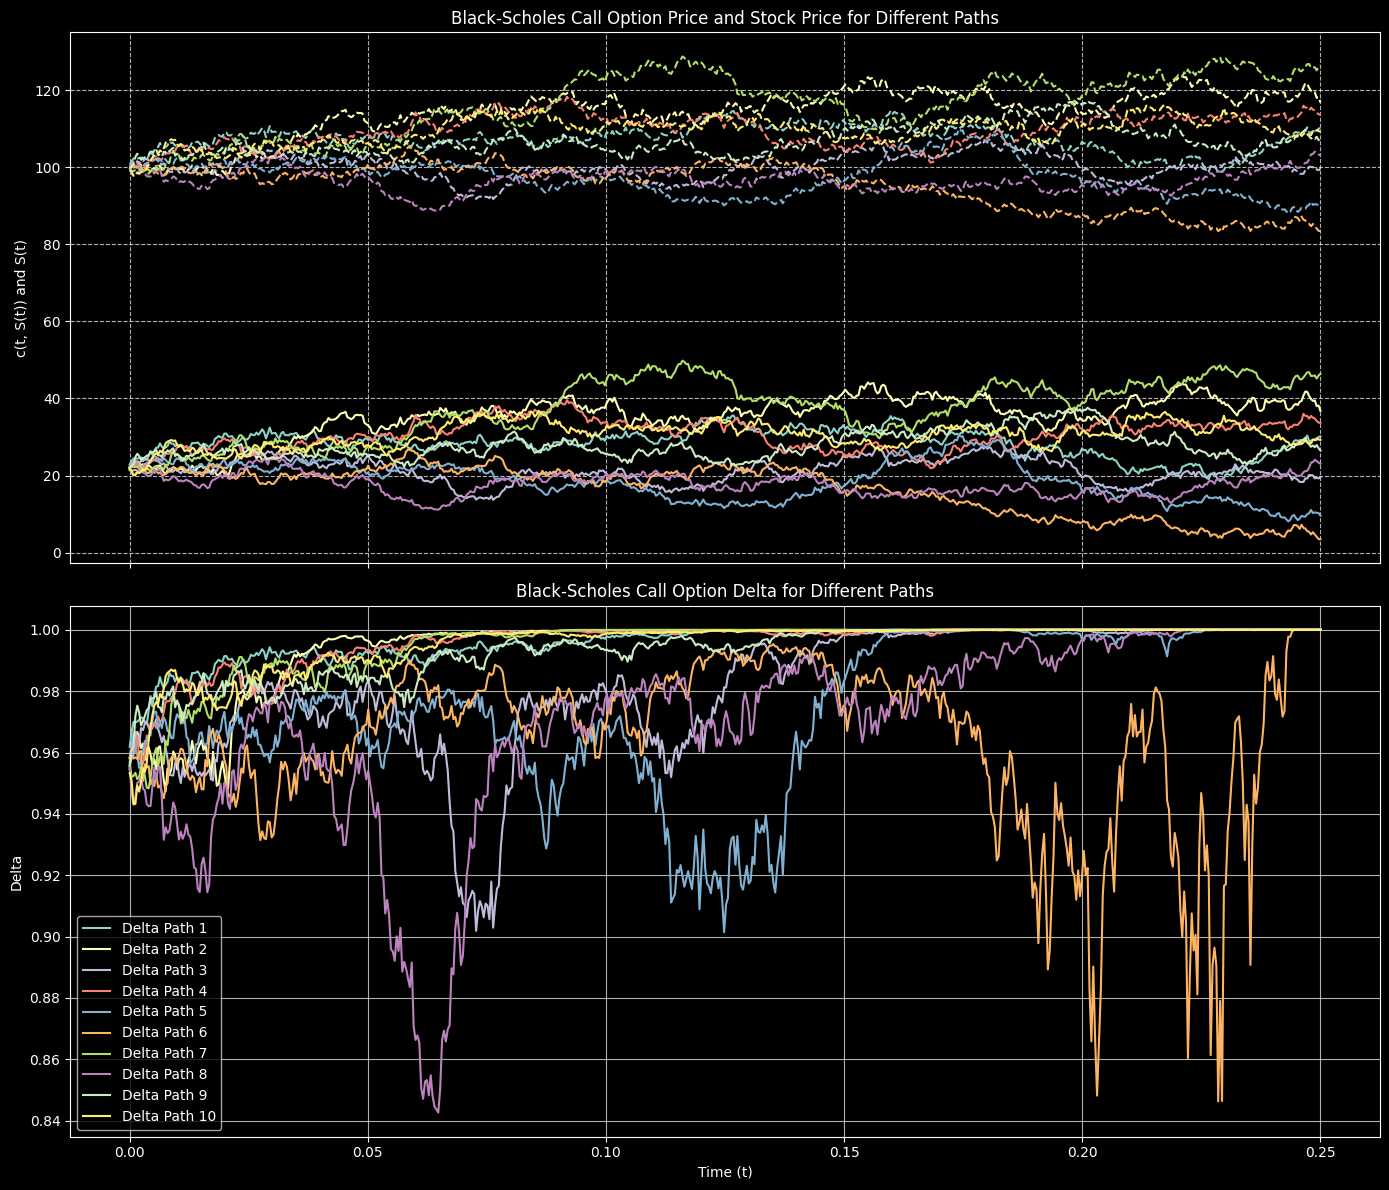

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define option parameters (from previous cells)
S0 = 100
K = 80
sigma = 0.3
r = 0.1
T = 0.25 # Total time in years (3 months)
dt = 0.1/252

# Number of simulation paths
num_paths = 10

plt.style.use('dark_background')
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True) # Two subplots, sharing the x-axis

# Get the default color cycle for consistent coloring
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

all_delta_values = []
all_time_points = []
all_stock_prices = [] # Added: to store stock prices for each path

for i in range(num_paths):
    # Simulate a new stock price path
    path_sim = qf.simulations.GeometricBrownianMotion(S0, r, sigma, dt, T)
    stock_prices = path_sim.simulated_path
    all_stock_prices.append(stock_prices) # Added: Store the stock prices for the current path

    # Generate time points for the path (from t=0 to t=T)
    time_points = np.linspace(0, T, len(stock_prices))
    all_time_points.append(time_points)

    option_prices = []
    delta_values = []
    for j in range(len(stock_prices)):
        current_S = stock_prices[j]
        current_time_to_maturity = T - time_points[j]

        # Handle option price calculation
        if current_time_to_maturity <= 0:
            option_price = max(current_S - K, 0)
            delta = 1 if current_S > K else (0 if current_S < K else 0.5) # Delta at maturity
        else:
            option_price = black_scholes_call(current_S, K, sigma, r, current_time_to_maturity)
            d1 = (np.log(current_S/K) + (r + ((sigma**2)/2))*current_time_to_maturity) / (sigma * np.sqrt(current_time_to_maturity))
            delta = norm.cdf(d1)

        option_prices.append(option_price)
        delta_values.append(delta)
    all_delta_values.append(delta_values)

    # Get a color from the cycle for the current path
    color = colors[i % len(colors)]

    # Plot on the first subplot (Option Price and Stock Price)
    axes[0].plot(time_points, option_prices, linestyle='-', color=color)
    axes[0].plot(time_points, stock_prices, linestyle='--', color=color)

    # Plot on the second subplot (Delta)
    axes[1].plot(time_points, delta_values, label=f'Delta Path {i+1}', linestyle='-', color=color)

# --- Configure the first subplot ---
axes[0].set_title('Black-Scholes Call Option Price and Stock Price for Different Paths')
axes[0].set_ylabel('c(t, S(t)) and S(t)')
axes[0].grid(True, linestyle='--', alpha=0.7)
#axes[0].legend() # Removed legend for the first subplot

# --- Configure the second subplot ---
axes[1].set_title('Black-Scholes Call Option Delta for Different Paths')
axes[1].set_xlabel('Time (t)')
axes[1].set_ylabel('Delta')
axes[1].grid(True, linestyle='-', alpha=0.7)
axes[1].legend() # Re-added legend for the second subplot

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
fig.savefig('/content/option_delta_plots.png') # Save plot
plt.show()

In [7]:
k = 0.1

all_transaction_costs = []
max_transaction_cost=0.0; # Initialize as float

for path_idx, delta_path in enumerate(all_delta_values):
    path_transaction_cost = 0
    # Retrieve the corresponding stock prices for this path
    stock_prices_for_path = all_stock_prices[path_idx]

    for i in range(1, len(delta_path)):
        change_in_delta = abs(delta_path[i] - delta_path[i-1])
        # Multiply by the stock price in the i'th interval
        path_transaction_cost += (k / 2) * change_in_delta * stock_prices_for_path[i]
    max_transaction_cost = max(max_transaction_cost, path_transaction_cost); # Use built-in max function
    all_transaction_costs.append(path_transaction_cost)

for i, cost in enumerate(all_transaction_costs):
    print(f"Path {i+1} Total Transaction Cost: {cost:.6f}")

print(f"Max Transaction Cost: {max_transaction_cost:.6f}");

Path 1 Total Transaction Cost: 1.234590
Path 2 Total Transaction Cost: 1.482013
Path 3 Total Transaction Cost: 4.703029
Path 4 Total Transaction Cost: 1.235694
Path 5 Total Transaction Cost: 6.259580
Path 6 Total Transaction Cost: 13.080784
Path 7 Total Transaction Cost: 1.395974
Path 8 Total Transaction Cost: 7.510991
Path 9 Total Transaction Cost: 2.017956
Path 10 Total Transaction Cost: 1.304883
Max Transaction Cost: 13.080784


### Delta Hedging Strategy Simulation
We define the portfolio as:
$$P_t = \Delta_t S_t + (C_t - \Delta_t S_t)$$
Where $\Delta_t$ is the Black-Scholes Delta. We will analyze the Hedging Error:
$$\Delta H = \Delta P - \Delta C$$

In [8]:
import pandas as pd

def simulate_hedging_error(S0, K, sigma, r, T, dt_val, num_paths=100):
    errors = []
    for _ in range(num_paths):
        path_sim = qf.simulations.GeometricBrownianMotion(S0, r, sigma, dt_val, T)
        S = path_sim.simulated_path
        t_pts = np.linspace(0, T, len(S))

        # Initial Setup
        C0 = black_scholes_call(S[0], K, sigma, r, T)
        d1_0 = (np.log(S[0]/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
        delta0 = norm.cdf(d1_0)

        # Portfolio components: Shares and Bank
        portfolio_value = C0
        shares = delta0
        bank = C0 - shares * S[0]

        path_errors = []

        for i in range(1, len(S)):
            # Delta P: Change in portfolio
            prev_P = portfolio_value
            # Bank grows at risk-free rate
            bank *= np.exp(r * dt_val)
            portfolio_value = shares * S[i] + bank
            delta_P = portfolio_value - prev_P

            # Delta C: Change in theoretical option price
            time_left_prev = T - t_pts[i-1]
            time_left_curr = T - t_pts[i]
            C_prev = black_scholes_call(S[i-1], K, sigma, r, max(time_left_prev, 1e-9))
            C_curr = black_scholes_call(S[i], K, sigma, r, max(time_left_curr, 0))
            delta_C = C_curr - C_prev

            path_errors.append(delta_P - delta_C)

            # Rebalance Delta for next step
            if time_left_curr > 0:
                d1_new = (np.log(S[i]/K) + (r + 0.5*sigma**2)*time_left_curr) / (sigma * np.sqrt(time_left_curr))
                shares = norm.cdf(d1_new)
                bank = portfolio_value - shares * S[i]

        errors.append(np.sum(path_errors))

    return np.mean(errors), np.var(errors)

# Parameters for the table
maturities = [1.0, 0.5, 0.25]  # 12m, 6m, 3m
revisions = [1/252, 5/252, 21/252] # Daily, Weekly, Monthly
results = []

for T_val in maturities:
    for dt_val in revisions:
        mean_err, var_err = simulate_hedging_error(100, 100, 0.3, 0.05, T_val, dt_val)
        results.append({"Maturity (Y)": T_val, "Revision (Y)": round(dt_val, 4), "E[ΔH]": mean_err, "Var(ΔH)": var_err})

df_results = pd.DataFrame(results)
display(df_results)

,Maturity (Y),Revision (Y),E[ΔH],Var(ΔH)
0,1.00,0.0040,0.160192,0.324912
1,1.00,0.0198,0.329069,1.931870
2,1.00,0.0833,0.367429,8.202628
3,0.50,0.0040,-0.002702,0.383310
4,0.50,0.0198,0.219706,2.333510
5,0.50,0.0833,0.536332,8.575514
6,0.25,0.0040,-0.021467,0.502229
7,0.25,0.0198,0.371520,1.526191
8,0.25,0.0833,1.142036,4.964213


### Visualizing Strategy $P$ vs. Option Price $C$
In the following plots, we compare the value of the hedging portfolio $P_t$ (rebalanced at discrete intervals) against the theoretical Black-Scholes price $C_t$. We use linear interpolation to visualize the portfolio value between the discrete rebalancing steps.

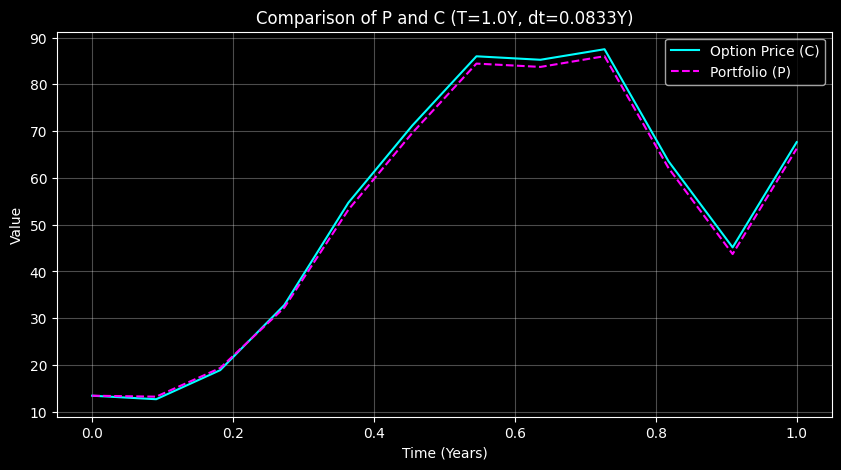

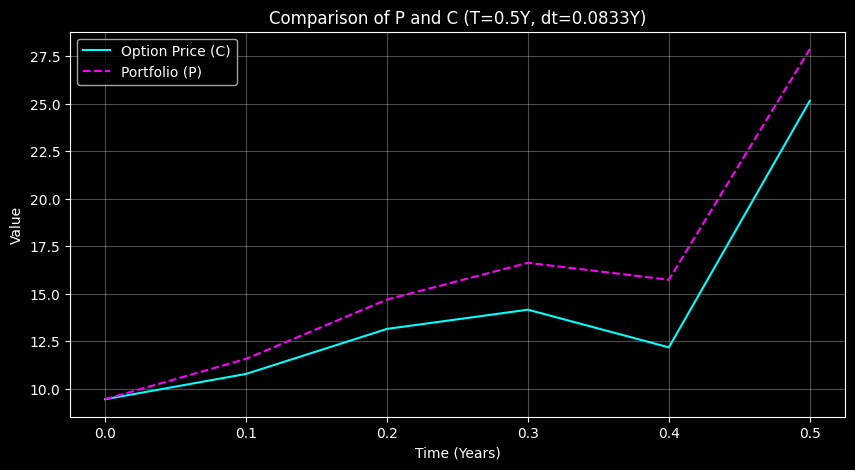

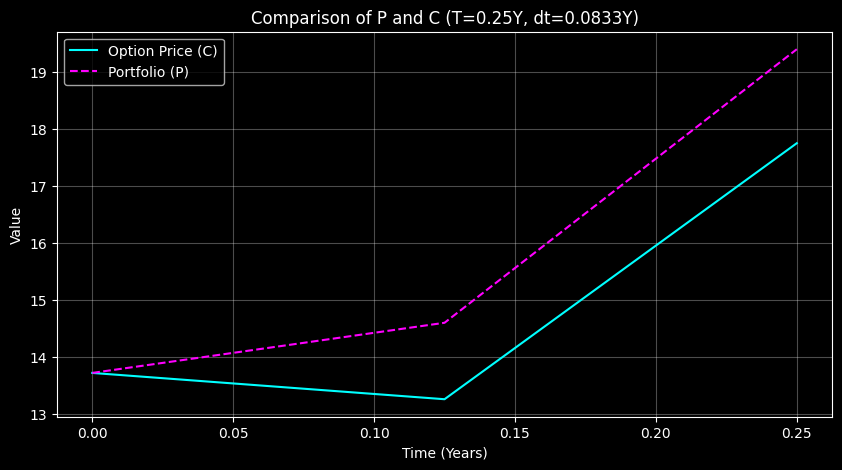

In [9]:
import matplotlib.pyplot as plt

def plot_p_vs_c(S0, K, sigma, r, T, dt_val):
    # Simulate one path
    path_sim = qf.simulations.GeometricBrownianMotion(S0, r, sigma, dt_val, T)
    S = path_sim.simulated_path
    t_pts = np.linspace(0, T, len(S))

    C_values = []
    P_values = []

    # Initial Setup
    C0 = black_scholes_call(S[0], K, sigma, r, T)
    d1_0 = (np.log(S[0]/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    delta0 = norm.cdf(d1_0)

    portfolio_value = C0
    shares = delta0
    bank = C0 - shares * S[0]

    C_values.append(C0)
    P_values.append(portfolio_value)

    for i in range(1, len(S)):
        # Portfolio value before rebalancing
        # Note: Bank grows between steps, but we evaluate P_t at each simulation step
        # Since the simulation 'dt' matches the 'dt_val' here, we rebalance every step
        current_P = shares * S[i] + bank * np.exp(r * dt_val)
        P_values.append(current_P)

        # Option price at current time
        time_left = max(T - t_pts[i], 0)
        current_C = black_scholes_call(S[i], K, sigma, r, time_left)
        C_values.append(current_C)

        # Rebalance for next step
        if time_left > 0:
            d1_new = (np.log(S[i]/K) + (r + 0.5*sigma**2)*time_left) / (sigma * np.sqrt(time_left))
            shares = norm.cdf(d1_new)
            bank = current_P - shares * S[i]
        portfolio_value = current_P

    plt.figure(figsize=(10, 5))
    plt.plot(t_pts, C_values, label='Option Price (C)', color='cyan')
    plt.plot(t_pts, P_values, label='Portfolio (P)', color='magenta', linestyle='--')
    plt.title(f'Comparison of P and C (T={T}Y, dt={round(dt_val, 4)}Y)')
    plt.xlabel('Time (Years)')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plotting for 12m, 6m, 3m with Daily Rebalancing
for T_v in [1.0, 0.5, 0.25]:
    plot_p_vs_c(100, 100, 0.3, 0.05, T_v, 21/252)

### Comparing Original Black-Scholes Call Price with a Modified Volatility Term for Transaction Costs

We will compare the Black-Scholes call option price calculated using the original volatility ($\\sigma$) with a price calculated using a modified volatility term ($\\sigma' = \\sigma + k$), where $k$ represents a transaction cost factor from earlier in the notebook.

In [13]:
import numpy as np
from scipy.stats import norm

# Assuming black_scholes_call function is defined in a previous cell
# Define the original option parameters
S = 100  # Current stock price
K = 100  # Strike price
sigma = 0.3  # Original volatility (from initial Black-Scholes call)
r = 0.05 # Risk-free rate
t = 1    # Time to maturity (in years)

# Transaction cost factor 'k' from cell 4TbvaYOFpRIh
k = 0.1

# Calculate the original Black-Scholes call price
original_call_price = black_scholes_call(S, K, sigma, r, t)

# Calculate the modified volatility
sigma_modified = sigma + k

# Calculate the Black-Scholes call price with modified volatility
modified_call_price = black_scholes_call(S, K, sigma_modified, r, t)

print(f"Original Volatility (sigma): {sigma:.2f}")
print(f"Modified Volatility (sigma + k): {sigma_modified:.2f}")
print(f"Black-Scholes Call Price (Original Volatility): {original_call_price:.4f}")
print(f"Black-Scholes Call Price (Modified Volatility): {modified_call_price:.4f}")
print(f"Difference: {modified_call_price - original_call_price:.4f}")

Original Volatility (sigma): 0.30
Modified Volatility (sigma + k): 0.40
Black-Scholes Call Price (Original Volatility): 14.2313
Black-Scholes Call Price (Modified Volatility): 18.0230
Difference: 3.7917


### Visualizing the Impact of Transaction Costs on Option Price Paths

We will now simulate a stock price path and compare how the Black-Scholes call option price $C(t, S_t)$ (using original volatility $\sigma$) evolves compared to a call option price $\hat{C}(t, S_t)$ (using a modified volatility $\sigma + k$) that accounts for transaction costs.

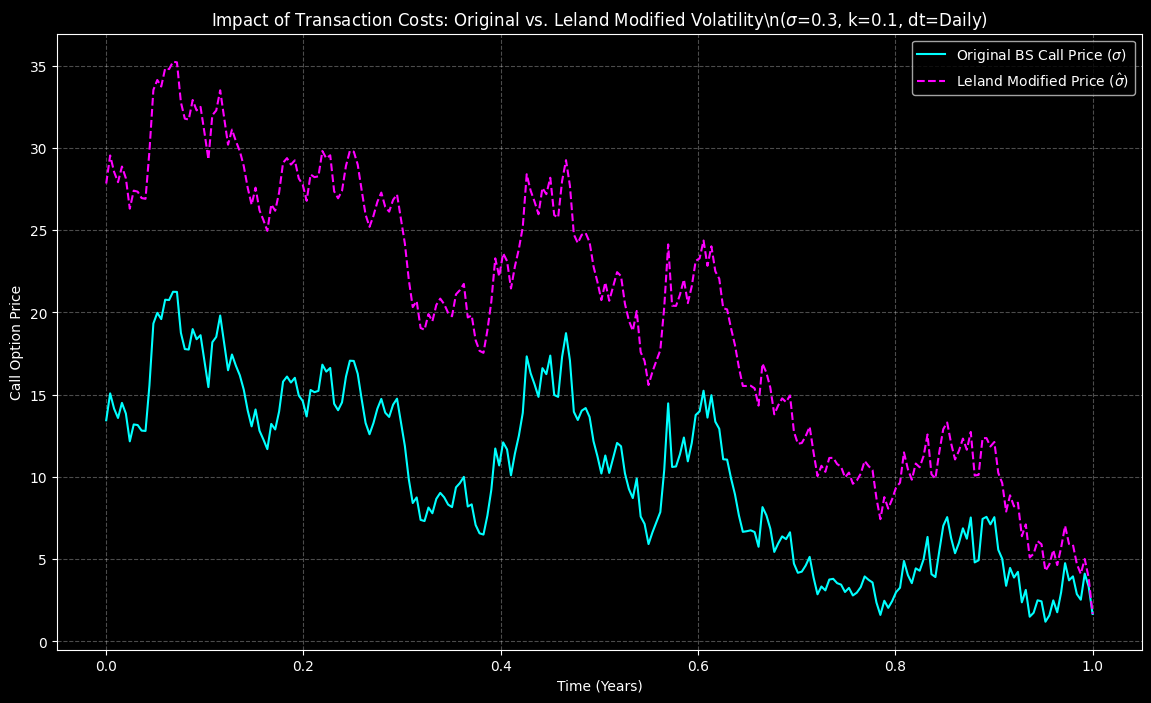

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Define option parameters
S0 = 100
K = 100
sigma_original = 0.3
r = 0.05
T = 1
dt_val = 1/252
k = 0.1

# Correct Leland Volatility calculation for the plot
leland_term = k * np.sqrt(2 / np.pi) / (sigma_original * np.sqrt(dt_val))
sigma_modified = sigma_original * np.sqrt(1 + leland_term)

plt.figure(figsize=(14, 8))
plt.style.use('dark_background')

# Simulate one stock price path
path_sim = qf.simulations.GeometricBrownianMotion(S0, r, sigma_original, dt_val, T)
S_path = path_sim.simulated_path
t_pts = np.linspace(0, T, len(S_path))

original_C_values = []
modified_C_values = []

for j in range(len(S_path)):
    current_S = S_path[j]
    time_left = max(T - t_pts[j], 0)

    # Original BS Price
    original_C_values.append(black_scholes_call(current_S, K, sigma_original, r, time_left))

    # Modified BS Price (Leland)
    modified_C_values.append(black_scholes_call(current_S, K, sigma_modified, r, time_left))

plt.plot(t_pts, original_C_values, label='Original BS Call Price ($\\sigma$)', color='cyan')
plt.plot(t_pts, modified_C_values, label='Leland Modified Price ($\\hat{\\sigma}$)', color='magenta', linestyle='--')

plt.title(f'Impact of Transaction Costs: Original vs. Leland Modified Volatility\\n($\\sigma$={sigma_original}, k={k}, dt=Daily)')
plt.xlabel('Time (Years)')
plt.ylabel('Call Option Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Comprehensive Hedging Error Simulation with Transaction Costs
We will now simulate the hedging error for different combinations of:
- **Transaction Cost Factors ($k$):** 0.25, 0.3, 0.35, 0.4
- **Maturities ($T$):** 12 months (1.0Y), 6 months (0.5Y), 3 months (0.25Y)
- **Revision Periods ($dt$):** 1 week (5/252Y), 4 weeks (20/252Y)

In [39]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from google.colab import files

def simulate_hedging_with_costs(S0, K, sigma, r, T, dt_val, k_factor, num_paths=100):
    errors = []
    costs = []

    # Correct Leland Volatility: sigma_hat^2 = sigma^2 * (1 + k * sqrt(2/pi) / (sigma * sqrt(dt)))
    leland_term = k_factor * np.sqrt(2 / np.pi) / (sigma * np.sqrt(dt_val))
    sigma_mod = sigma * np.sqrt(1 + leland_term)

    for _ in range(num_paths):
        path_sim = qf.simulations.GeometricBrownianMotion(S0, r, sigma, dt_val, T)
        S = path_sim.simulated_path
        t_pts = np.linspace(0, T, len(S))

        # Initial Portfolio Setup using Corrected Modified Volatility
        C0 = black_scholes_call(S[0], K, sigma_mod, r, T)
        d1_0 = (np.log(S[0]/K) + (r + 0.5 * sigma_mod**2) * T) / (sigma_mod * np.sqrt(T))
        shares = norm.cdf(d1_0)
        bank = C0 - shares * S[0]
        portfolio_value = C0

        path_errors = []
        path_cost = 0

        for i in range(1, len(S)):
            prev_P = portfolio_value
            bank *= np.exp(r * dt_val)
            portfolio_value = shares * S[i] + bank
            delta_P = portfolio_value - prev_P

            # Theoretical price change (original volatility)
            time_left_prev = max(T - t_pts[i-1], 1e-9)
            time_left_curr = max(T - t_pts[i], 0)
            C_prev = black_scholes_call(S[i-1], K, sigma, r, time_left_prev)
            C_curr = black_scholes_call(S[i], K, sigma, r, time_left_curr)
            delta_C = C_curr - C_prev

            path_errors.append(delta_P - delta_C)

            # Rebalance using Corrected Modified Volatility
            if time_left_curr > 0:
                d1_new = (np.log(S[i]/K) + (r + 0.5 * sigma_mod**2) * time_left_curr) / (sigma_mod * np.sqrt(time_left_curr))
                new_shares = norm.cdf(d1_new)
                # Transaction cost per unit: (k/2) * S * |change in delta|
                path_cost += (k_factor / 2) * abs(new_shares - shares) * S[i]
                shares = new_shares
                bank = portfolio_value - shares * S[i]

        errors.append(np.sum(path_errors))
        costs.append(path_cost)

    return np.mean(errors), np.var(errors), np.mean(costs)

# Parameter Grids
k_values = [0.25, 0.3, 0.35, 0.4]
maturities = [1.0, 0.5, 0.25]
revisions = [5/252, 20/252]
strikes = [80, 90, 100, 110, 120]

all_results = []
S0_val, r_val, sigma_val = 100, 0.05, 0.3

for k in k_values:
    for T_val in maturities:
        for dt_val in revisions:
            for K_val in strikes:
                m_err, v_err, m_cost = simulate_hedging_with_costs(S0_val, K_val, sigma_val, r_val, T_val, dt_val, k)
                all_results.append({
                    "k": k,
                    "Maturity (Y)": T_val,
                    "Revision (Y)": round(dt_val, 4),
                    "K": K_val,
                    "E[ΔH]": m_err,
                    "Var(ΔH)": v_err,
                    "Avg Transaction Cost": m_cost
                })

df_extended_results = pd.DataFrame(all_results)
display(df_extended_results)

# Save to Excel
excel_file = 'hedging_results_corrected.xlsx'
df_extended_results.to_excel(excel_file, index=False)
files.download(excel_file)

,k,Maturity (Y),Revision (Y),K,E[ΔH],Var(ΔH),Avg Transaction Cost
0,0.25,1.00,0.0198,80,0.353320,10.186622,11.646593
1,0.25,1.00,0.0198,90,1.326332,11.757799,14.402283
2,0.25,1.00,0.0198,100,1.626957,13.948952,16.301445
3,0.25,1.00,0.0198,110,0.710389,20.562050,16.199332
4,0.25,1.00,0.0198,120,-0.317525,28.116037,15.693128
...,...,...,...,...,...,...,...
115,0.40,0.25,0.0794,80,0.569511,4.010106,1.708846
116,0.40,0.25,0.0794,90,0.909112,7.393212,1.922767
117,0.40,0.25,0.0794,100,1.162731,8.070797,2.244063
118,0.40,0.25,0.0794,110,0.953149,10.385683,2.452080


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>